# Un receptor a fondo: Ja'Marr Chase

## Qué responde este notebook

Los notebooks 2.1 a 2.5 describen a todos los receptores. Aquí se mira uno solo, para ver en un caso
concreto cómo se ve una semana extrema frente a una común. Chase se eligió por datos: entre los
receptores con al menos 15 semanas con pases dirigidos en 2024-2025, es el de mayor diferencia entre
su mejor y su peor semana en yardas (sección 0).

Es un caso ilustrativo, no una prueba sobre todos los receptores; la revisión sistemática está en
[`2.5_eda_multivariable.ipynb`](2.5_eda_multivariable.ipynb).

In [1]:
import sys
import logging
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sportypy.surfaces.football import FootballField

import data

sns.set_style("whitegrid")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

CHASE_ID = "00-0036900"
stats = data.cargar_stats_semanales([2024, 2025])
chase = stats[stats["player_id"] == CHASE_ID].sort_values(["season", "week"]).reset_index(drop=True)
print("semanas con datos:", chase.shape[0])

semanas con datos: 33


## 0. Por qué él

Entre los receptores con al menos 15 semanas con pases dirigidos en 2024-2025, la diferencia entre
su mejor y su peor semana en yardas, y las semanas que más se alejan del promedio del propio jugador.

In [2]:
wr = stats[(stats["position"] == "WR") & (stats["targets"] > 0)].copy()
por_jugador = wr.groupby(["player_id", "player_display_name"])["receiving_yards"].agg(
    semanas="count", mejor="max", peor="min", promedio="mean")
por_jugador = por_jugador[por_jugador["semanas"] >= 15]
por_jugador["rango"] = por_jugador["mejor"] - por_jugador["peor"]
print("mayor diferencia entre la mejor y la peor semana:")
print(por_jugador.sort_values("rango", ascending=False).head(5).round(1).to_string())
assert por_jugador["rango"].idxmax()[0] == CHASE_ID

wr["desviacion"] = wr["receiving_yards"] - wr.groupby("player_id")["receiving_yards"].transform("mean")
print("\nsemanas más por encima del promedio del propio jugador:")
print(wr.nlargest(3, "desviacion")[["player_display_name", "season", "week", "receiving_yards", "desviacion"]]
      .round(1).to_string(index=False))

mayor diferencia entre la mejor y la peor semana:
                                semanas  mejor  peor  promedio  rango
player_id  player_display_name                                       
00-0036900 Ja'Marr Chase             33    264    23      94.5    241
00-0036407 Jerry Jeudy               34    235     0      53.9    235
00-0039075 Puka Nacua                27    225    11     100.2    214
00-0031381 Davante Adams             28    198     1      66.1    197
00-0036963 Amon-Ra St. Brown         34    193     0      78.4    193

semanas más por encima del promedio del propio jugador:
player_display_name  season  week  receiving_yards  desviacion
        Jerry Jeudy    2024    13              235       181.1
      Ja'Marr Chase    2024    10              264       169.5
     Michael Wilson    2025    11              185       137.9


Chase tiene la mayor diferencia: 241 yardas entre su mejor semana (264) y su peor (23), por delante de
Jerry Jeudy (235) y Puka Nacua (214). Su semana 10 de 2024 es además la segunda que más se aleja del
promedio del propio jugador (+169.5 yardas), detrás de una de Jeudy (+181.1). Jeudy combina una semana
de 235 con una de 0 y un promedio de 53.9; Chase, un pico de 264 sobre un promedio alto (94.5).

## 1. Toda su trayectoria, 2024-2025

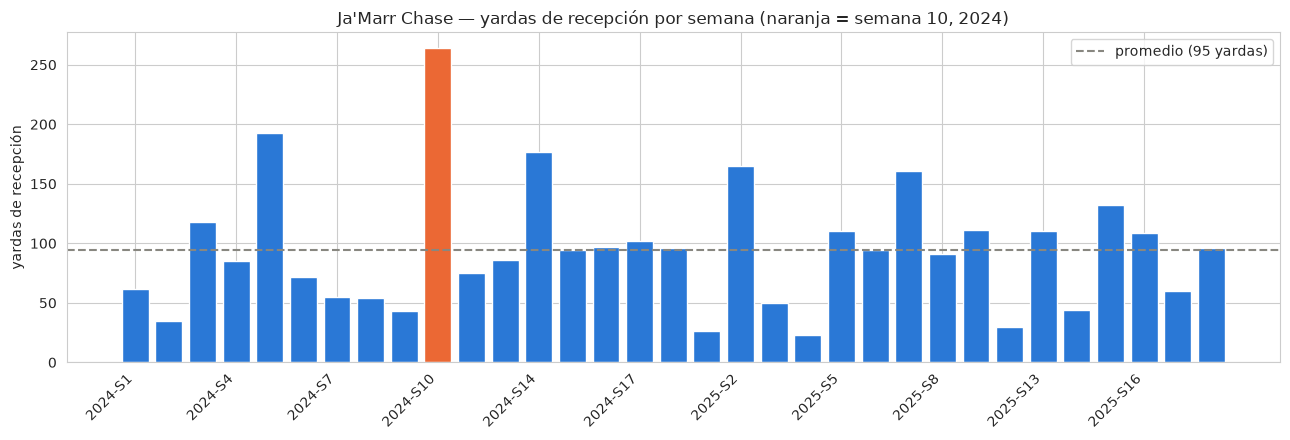

season             2024
week                 10
targets              17
receptions           11
receiving_yards     264
receiving_tds         3
Name: 9, dtype: object


In [3]:
fig, ax = plt.subplots(figsize=(13, 4.5))
x = range(len(chase))
colores = [NARANJA if (s == 2024 and w == 10) else AZUL for s, w in zip(chase["season"], chase["week"])]
ax.bar(x, chase["receiving_yards"], color=colores)
ax.axhline(chase["receiving_yards"].mean(), color=GRIS, linestyle="--", label=f"promedio ({chase['receiving_yards'].mean():.0f} yardas)")
ax.set_xticks(list(x)[::3])
ax.set_xticklabels([f"{s}-S{w}" for s, w in zip(chase["season"], chase["week"])][::3], rotation=45, ha="right")
ax.set_ylabel("yardas de recepción")
ax.set_title("Ja'Marr Chase — yardas de recepción por semana (naranja = semana 10, 2024)")
ax.legend()
plt.tight_layout()
plt.show()

print(chase.loc[chase["receiving_yards"].idxmax(), ["season", "week", "targets", "receptions", "receiving_yards", "receiving_tds"]])

**Semana 10 de 2024**: 17 pases dirigidos, 11 recepciones, **264 yardas** y 3 touchdowns, casi el
triple de su promedio de esas dos temporadas (la línea punteada, unas 95 yardas). Es el pico de toda
su trayectoria en la gráfica.

## 2. Ese partido en el campo, frente a una semana por debajo de su promedio

Cada punto es un pase dirigido a Chase. A lo largo del campo se ubica en la yarda a la que llegó el
pase: desde dónde arrancó la jugada (`yardline_100`) más la profundidad del pase (`air_yards`). A lo
ancho, el dato público solo dice el lado (`pass_location`: izquierda, centro o derecha), así que
dentro de cada lado la posición es aleatoria, para no aparentar una precisión que los datos no
tienen; las coordenadas exactas solo existen en datos de rastreo que no son públicos.

Se compara la semana 10 contra la semana 6 del mismo año: 72 yardas, por debajo de su promedio.

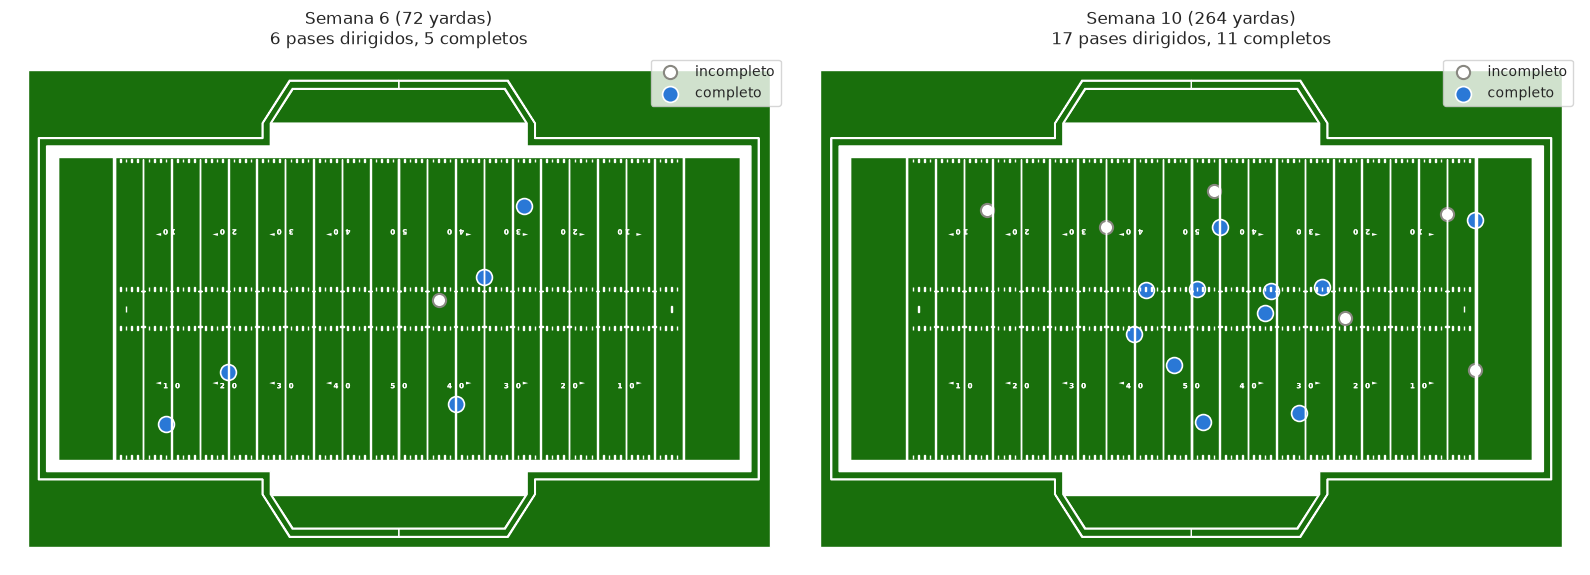

In [4]:
pbp24 = data.cargar_jugadas([2024])
chase_pbp = pbp24[(pbp24["receiver_id"] == CHASE_ID) & (pbp24["pass_attempt"] == 1)].copy()

def preparar_targets(df_semana, rng):
    d = df_semana.dropna(subset=["air_yards", "pass_location", "yardline_100"]).copy()
    posicion_final = d["yardline_100"] - d["air_yards"]
    d["x"] = 50 - posicion_final
    lado_centro = d["pass_location"].map({"left": -15, "middle": 0, "right": 15})
    d["y"] = lado_centro + rng.uniform(-6, 6, size=len(d))
    return d

rng = np.random.default_rng(42)
wk10 = preparar_targets(chase_pbp[chase_pbp["week"] == 10], rng)
wk6 = preparar_targets(chase_pbp[chase_pbp["week"] == 6], rng)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, datos, titulo in [(axes[0], wk6, "Semana 6 (72 yardas)"),
                           (axes[1], wk10, "Semana 10 (264 yardas)")]:
    field = FootballField(league_code="nfl")
    field.draw(ax=ax, display_range="full")
    completos = datos[datos["complete_pass"] == 1]
    incompletos = datos[datos["complete_pass"] == 0]
    ax.scatter(incompletos["x"], incompletos["y"], facecolor="white", edgecolor=GRIS, linewidth=1.5, s=90, label="incompleto", zorder=5)
    ax.scatter(completos["x"], completos["y"], color=AZUL, edgecolor="white", linewidth=1.2, s=130, label="completo", zorder=5)
    ax.set_title(f"{titulo}\n{len(datos)} pases dirigidos, {len(completos)} completos")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Lectura.** En la semana 10 le lanzaron 17 pases y atrapó 11, contra 6 y 5 en la semana 6, y los
pases se reparten por más zonas del campo. La diferencia más clara es de volumen. Como el gráfico no
separa la profundidad de cada pase del punto desde donde arrancó la jugada, no permite decir si los
pases de la semana 10 fueron más profundos.

## Cierre

- Chase se eligió por datos, como el receptor con la mayor diferencia entre su mejor y su peor semana
  entre los que tuvieron al menos 15 semanas con pases dirigidos en 2024-2025.
- Su semana 10 de 2024 (264 yardas) es casi el triple de su promedio. Frente a una semana por debajo
  de su promedio, la diferencia más clara es el volumen: 17 pases dirigidos contra 6.
- El gráfico de campo ubica cada pase en la yarda a la que llegó; el lado es aproximado, por la
  resolución de los datos públicos.

Es un caso ilustrativo, no una prueba estadística sobre todos los receptores.

Anterior: [`2.5_eda_multivariable.ipynb`](2.5_eda_multivariable.ipynb) · Siguiente:
[`3.1_ingenieria_features.ipynb`](3.1_ingenieria_features.ipynb)